# Import Libraries

In [1]:
import pandas as pd
import os
import pickle
import torch
from torch import nn
import numpy as np
from torch.utils.data import Dataset
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification, Trainer, TrainingArguments

c:\Users\VICTUS\OneDrive\Documents\Semester_4\ML\ML\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Load Dataset

In [2]:
train_df = pd.read_csv('../data/data_train_master.csv')
train_df.head(5)

,clean_text,emotion
0,thanks mate! i havent given that idea much tho...,Joy
1,feel you pain. stay strong,Sadness
2,i constantly feel like i'm my husband's best f...,Sadness
3,"been together 6 years, and i think she's the b...",Love
4,"amen! however, see my post about the problem w...",Sadness


# Data Splitting

We need a validation dataset because, in the later stage, the model performance will be evaluated during the Bayesian hyperparameter tuning process using Optuna. The validation data helps Optuna determine which parameter combination produces the best performance.

In [3]:
train_split, val_split = train_test_split(
    train_df, 
    test_size=0.2, 
    random_state=42, 
    stratify=train_df['emotion'] 
)

print(f"Train: {len(train_split)} rows")
print(f"Validation: {len(val_split)} rows")

Train: 24483 rows
Validation: 6121 rows


# Label Encoding

In [4]:
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(train_split['emotion'])
y_val_encoded = label_encoder.transform(val_split['emotion'])
num_classes = len(label_encoder.classes_)

# Tokenization

In [5]:
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

train_encodings = tokenizer(train_split['clean_text'].astype(str).tolist(), truncation=True, padding=True, max_length=60)
val_encodings = tokenizer(val_split['clean_text'].astype(str).tolist(), truncation=True, padding=True, max_length=60)

# Converting into PyTorch Dataset

In [6]:
class EmotionDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = EmotionDataset(train_encodings, y_train_encoded)
val_dataset = EmotionDataset(val_encodings, y_val_encoded)

# Custom Trainer w/ Focal Loss

To further improve the model performance on imbalanced emotion classes, we implement Focal Loss during the training process. Unlike standard Cross Entropy Loss, Focal Loss gives higher attention to hard-to-classify samples while reducing the influence of already well-classified samples. 

The parameter gamma controls how strongly the model focuses on difficult predictions. In this project, we use gamma = 2.0 to encourage the model to learn minority and challenging emotion classes more effectively.

In [7]:
import torch.nn.functional as F # Defining F for Optuna later

class FocalLossTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        
        # Focal Loss Math: (1 - pt)^gamma * CrossEntropy
        ce_loss = F.cross_entropy(logits, labels, reduction='none')
        pt = torch.exp(-ce_loss)
        gamma = 2.0 # Focus Degree for hard sentences
        focal_loss = ((1 - pt) ** gamma) * ce_loss
        loss = focal_loss.mean()
        
        return (loss, outputs) if return_outputs else loss

# Optuna Model Initializer

To optimize the DistilBERT model further, we use Optuna for automatic hyperparameter tuning. The `model_init()` function is used to create a fresh DistilBERT model for every trial conducted by Optuna. 

Meanwhile, the `optuna_hp_space()` function defines the hyperparameter search space, including learning rate, batch size, and weight decay. Optuna will automatically explore different parameter combinations to find the most optimal configuration for the model performance.

In [8]:
def model_init():
    return DistilBertForSequenceClassification.from_pretrained(
        'distilbert-base-uncased', 
        num_labels=num_classes
    )

In [9]:
def optuna_hp_space(trial):
    return {
        "learning_rate": trial.suggest_float("learning_rate", 1e-5, 5e-5, log=True),
        "per_device_train_batch_size": trial.suggest_categorical("per_device_train_batch_size", [16, 32]),
        "weight_decay": trial.suggest_float("weight_decay", 0.01, 0.1)
    }

# Training Arguments

In [10]:
training_args = TrainingArguments(
    output_dir='../models/distilbert_optuna/trials',
    num_train_epochs=3, 
    report_to="none",
    fp16=True,
    evaluation_strategy="epoch",
    save_strategy="epoch",
    disable_tqdm=True 
)

c:\Users\VICTUS\OneDrive\Documents\Semester_4\ML\ML\lib\site-packages\transformers\training_args.py:1474: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


# Optuna Execution

In [11]:
trainer = FocalLossTrainer(
    model=None, # Dikosongkan karena menggunakan model_init
    model_init=model_init,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset 
)

c:\Users\VICTUS\OneDrive\Documents\Semester_4\ML\ML\lib\site-packages\accelerate\accelerator.py:479: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(**kwargs)
Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [12]:
best_run = trainer.hyperparameter_search(
    direction="maximize", 
    backend="optuna", 
    hp_space=optuna_hp_space, 
    n_trials=5 # Training 5 times with different combination
)

[I 2026-05-30 11:12:39,612] A new study created in memory with name: no-name-94f538d6-bf47-42ea-b73e-f7c49ce2217a
Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


{'loss': 0.584, 'grad_norm': 7.289797306060791, 'learning_rate': 1.7543431636144854e-05, 'epoch': 0.32658393207054215}
{'loss': 0.4317, 'grad_norm': 6.82750940322876, 'learning_rate': 1.5400853273156963e-05, 'epoch': 0.6531678641410843}
{'loss': 0.4169, 'grad_norm': 4.307662487030029, 'learning_rate': 1.3258274910169072e-05, 'epoch': 0.9797517962116263}
{'eval_loss': 0.391450434923172, 'eval_runtime': 5.322, 'eval_samples_per_second': 1150.13, 'eval_steps_per_second': 143.931, 'epoch': 1.0}
{'loss': 0.3374, 'grad_norm': 6.606099605560303, 'learning_rate': 1.1115696547181178e-05, 'epoch': 1.3063357282821686}
{'loss': 0.3163, 'grad_norm': 2.8360633850097656, 'learning_rate': 8.973118184193289e-06, 'epoch': 1.6329196603527105}
{'loss': 0.3194, 'grad_norm': 7.035236835479736, 'learning_rate': 6.8348249779313725e-06, 'epoch': 1.959503592423253}
{'eval_loss': 0.3813759684562683, 'eval_runtime': 8.1679, 'eval_samples_per_second': 749.395, 'eval_steps_per_second': 93.781, 'epoch': 2.0}
{'loss'

[I 2026-05-30 11:17:38,017] Trial 0 finished with value: 0.3969261348247528 and parameters: {'learning_rate': 1.968172484240677e-05, 'per_device_train_batch_size': 16, 'weight_decay': 0.08299601521554262}. Best is trial 0 with value: 0.3969261348247528.


{'train_runtime': 297.554, 'train_samples_per_second': 246.843, 'train_steps_per_second': 15.436, 'train_loss': 0.3494614618369081, 'epoch': 3.0}


c:\Users\VICTUS\OneDrive\Documents\Semester_4\ML\ML\lib\site-packages\accelerate\accelerator.py:479: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(**kwargs)
Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


...

{'train_runtime': 293.4409, 'train_samples_per_second': 250.303, 'train_steps_per_second': 15.652, 'train_loss': 0.37722170236140273, 'epoch': 3.0}


c:\Users\VICTUS\OneDrive\Documents\Semester_4\ML\ML\lib\site-packages\accelerate\accelerator.py:479: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(**kwargs)
Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


{'loss': 0.5534, 'grad_norm': 8.12926197052002, 'learning_rate': 2.694347855330989e-05, 'epoch': 0.32658393207054215}
{'loss': 0.4315, 'grad_norm': 5.606343746185303, 'learning_rate': 2.3652872965460613e-05, 'epoch': 0.6531678641410843}
{'loss': 0.4155, 'grad_norm': 4.007287502288818, 'learning_rate': 2.0362267377611336e-05, 'epoch': 0.9797517962116263}
{'eval_loss': 0.38932448625564575, 'eval_runtime': 6.9891, 'eval_samples_per_second': 875.791, 'eval_steps_per_second': 109.599, 'epoch': 1.0}
{'loss': 0.3204, 'grad_norm': 6.361078262329102, 'learning_rate': 1.7071661789762056e-05, 'epoch': 1.3063357282821686}
{'loss': 0.301, 'grad_norm': 4.794033527374268, 'learning_rate': 1.3787637413088476e-05, 'epoch': 1.6329196603527105}
{'loss': 0.3009, 'grad_norm': 5.2553391456604, 'learning_rate': 1.0497031825239197e-05, 'epoch': 1.959503592423253}
{'eval_loss': 0.38468873500823975, 'eval_runtime': 5.946, 'eval_samples_per_second': 1029.434, 'eval_steps_per_second': 128.826, 'epoch': 2.0}
{'los

[I 2026-05-30 11:33:37,602] Trial 4 finished with value: 0.4105769693851471 and parameters: {'learning_rate': 3.022750292998347e-05, 'per_device_train_batch_size': 16, 'weight_decay': 0.04802467932293302}. Best is trial 4 with value: 0.4105769693851471.


{'train_runtime': 290.3305, 'train_samples_per_second': 252.984, 'train_steps_per_second': 15.82, 'train_loss': 0.32860544546481546, 'epoch': 3.0}


In [13]:
print("\n=== Optimization Done ===")
print("Best Hyperparameter:", best_run.hyperparameters)


=== Optimization Done ===
Best Hyperparameter: {'learning_rate': 3.022750292998347e-05, 'per_device_train_batch_size': 16, 'weight_decay': 0.04802467932293302}


# Final Training

Lastly, we retrain the model using the best hyperparameter configuration obtained from the Optuna tuning process.

In [14]:
final_training_args = TrainingArguments(
    output_dir='../models/distilbert_optuna/final_run',
    num_train_epochs=3,
    per_device_train_batch_size=best_run.hyperparameters['per_device_train_batch_size'],
    learning_rate=best_run.hyperparameters['learning_rate'],
    weight_decay=best_run.hyperparameters['weight_decay'],
    report_to="none",
    fp16=True,
    disable_tqdm=False # Menyalakan bar progress agar kamu bisa lihat prosesnya
)

In [15]:
final_trainer = FocalLossTrainer(
    model=model_init(),
    args=final_training_args,
    train_dataset=train_dataset,
)
final_trainer.train()

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
c:\Users\VICTUS\OneDrive\Documents\Semester_4\ML\ML\lib\site-packages\accelerate\accelerator.py:479: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(**kwargs)
 11%|█         | 500/4593 [00:29<03:58, 17.15it/s]

{'loss': 0.5626, 'grad_norm': 6.779155254364014, 'learning_rate': 2.694347855330989e-05, 'epoch': 0.33}


 22%|██▏       | 1000/4593 [00:59<03:43, 16.05it/s]

{'loss': 0.433, 'grad_norm': 5.432981014251709, 'learning_rate': 2.3652872965460613e-05, 'epoch': 0.65}


 33%|███▎      | 1500/4593 [01:28<02:58, 17.35it/s]

...

 98%|█████████▊| 4500/4593 [04:33<00:05, 17.06it/s]

{'loss': 0.2149, 'grad_norm': 9.650259017944336, 'learning_rate': 6.317962728670614e-07, 'epoch': 2.94}


100%|██████████| 4593/4593 [04:40<00:00, 16.38it/s]

{'train_runtime': 280.3431, 'train_samples_per_second': 261.997, 'train_steps_per_second': 16.383, 'train_loss': 0.32955741176360215, 'epoch': 3.0}


TrainOutput(global_step=4593, training_loss=0.32955741176360215, metrics={'train_runtime': 280.3431, 'train_samples_per_second': 261.997, 'train_steps_per_second': 16.383, 'total_flos': 1140268595877360.0, 'train_loss': 0.32955741176360215, 'epoch': 3.0})

# Evaluation

## Load Data Test

In [16]:
test_df = pd.read_csv('../data/data_test_master.csv')
test_df.head(5)

,clean_text,emotion
0,i love how adgag laws are legalized illegal ac...,Love
1,ah lol just run then,Joy
2,what a time to be alive,Surprise
3,i love this game but even i'm not spending mon...,Love
4,gotta get out on,Joy


In [17]:
X_test_text = test_df['clean_text'].astype(str).tolist()
y_test_text = test_df['emotion']

In [18]:
y_test_encoded = label_encoder.transform(y_test_text)
test_encodings = tokenizer(X_test_text, truncation=True, padding=True, max_length=60)
test_dataset = EmotionDataset(test_encodings, y_test_encoded)

## Prediction

In [19]:
predictions = final_trainer.predict(test_dataset)
y_pred_encoded = np.argmax(predictions.predictions, axis=1)
y_pred = label_encoder.inverse_transform(y_pred_encoded)

100%|██████████| 957/957 [00:08<00:00, 106.42it/s]


## Classification Report

In [20]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [21]:
print(f"\n=== Classification Report: DistilBERT (Optuna + Focal Loss) ===")
print(classification_report(y_test_text, y_pred, target_names=label_encoder.classes_))


=== Classification Report: DistilBERT (Optuna + Focal Loss) ===
              precision    recall  f1-score   support

       Anger       0.75      0.78      0.77      1618
        Fear       0.67      0.71      0.69       590
         Joy       0.81      0.70      0.75      1619
        Love       0.82      0.89      0.85      1496
     Sadness       0.74      0.72      0.73      1271
    Surprise       0.71      0.72      0.71      1058

    accuracy                           0.76      7652
   macro avg       0.75      0.75      0.75      7652
weighted avg       0.76      0.76      0.76      7652



## Confussion Matrix

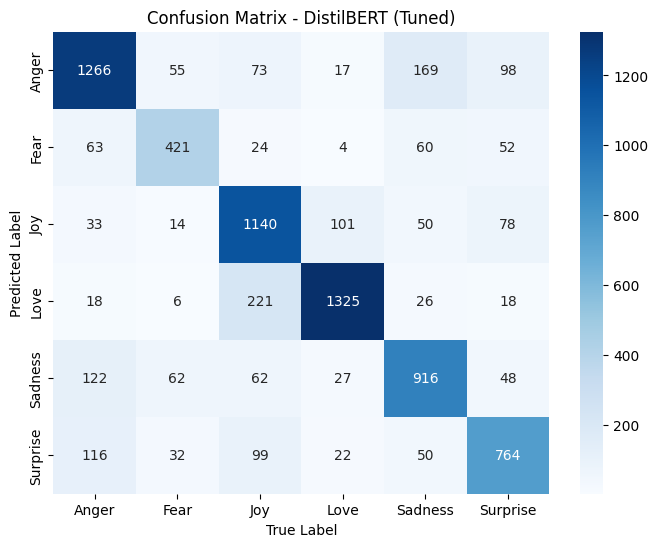

In [22]:
cm = confusion_matrix(y_test_text, y_pred).T
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=label_encoder.classes_, 
            yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix - DistilBERT (Tuned)')
plt.xlabel('True Label')
plt.ylabel('Predicted Label')
plt.show()

# Dump Model

In [23]:
trainer.save_model('../models/distilbert_optuna/best_model')
tokenizer.save_pretrained('../models/distilbert_optuna/best_model')

with open('../models/distilbert_optuna/best_model/label_encoder.pkl', 'wb') as f:
    pickle.dump(label_encoder, f, protocol=pickle.HIGHEST_PROTOCOL)